# Transformando Dados em Ações

## Conexão do jupyter notebook com o Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download do YOLOV5

In [2]:
! git clone https://github.com/ultralytics/yolov5.git

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 17898 (delta 47), reused 23 (delta 22), pack-reused 17829 (from 2)
Receiving objects: 100% (17898/17898), 17.03 MiB | 14.33 MiB/s, done.
Resolving deltas: 100% (12189/12189), done.


In [3]:
! pip install -r yolov5/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


## Arquivo YAML com as variáveis de configuração e saída

In [4]:
! cp /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/dados.yaml yolov5/data/

In [5]:
# Somente para evitar erros
!pip install -U albumentations

## Treinamento da Rede Yolo com 40 epochs

In [6]:
! python yolov5/train.py --data dados.yaml --weights yolov5s.pt --img 640 --epochs 40

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-28 15:25:48.550523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777389948.584415    1256 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777389948.595333    1256 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

### Resumo do treinamento da 1° Rede

1. Arquitetura
- 157 camadas - N° total de camadas da rede neural
- 7.018.216 parâmetros - Quantidade de pesos ajustáveis aprendidos.
- 0 gradientes - indica que o modelo não está sendo treinado no momento
- 15,8 GFLOPs - medida de complexidade computacional do modelo

2. Classificação dos resultados
- 3 Classes -> Carros, Motos e Tratores
- Imagens -> N° de imagens usado na avaliação
- P (Precisão) -> A previsão mostra que Motos teve 100% de precisão, seguido de Carros com 82% e Tratores com 29% de acerto com uma média de 70% para o contexto geral
- R (Recall) -> Carros atingiram positivamente 97% de detecção enquanto geral foi de 61%
- maP50 (Média de precisão média em IoU 0.5): Seguiu com uma média de 70% mas Carros se sobresaindo com uma média de 92,8%
- maP50-95 -> Carros ganhou com 60% enquanto Motos se saiu com 27,7%

### Teste da Rede Yolo com 40 epochs

In [7]:
import os
import subprocess

def get_latest_train_run_folder():
    subfolders = [f.path for f in os.scandir('yolov5/runs/train') if f.is_dir()]
    latest_folder = max(subfolders, key=os.path.getctime, default=None)
    return latest_folder

latest_run = get_latest_train_run_folder()
result = subprocess.run(f'python yolov5/detect.py --weights {latest_run}/weights/best.pt --img 640 --source drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/ --data yolov5/data/telhado.yaml', shell=True, capture_output=True, text=True)
if latest_run:
    # COMANDO
    result = subprocess.run(f'python yolov5/detect.py --weights {latest_run}/weights/best.pt --img 640 --source drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/ --data yolov5/data/telhado.yaml', shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
else:
    print("Não foi possível encontrar a pasta de treinamento mais recente.")


detect: weights=['yolov5/runs/train/exp/weights/best.pt'], source=drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/, data=yolov5/data/telhado.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
image 1/12 /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/Carros_5.jpg: 384x640 6 Carross, 62.3ms
image 2/12 /content/drive/MyDrive/Faculdades/FIAP/2_Seme

### Resumo da Validação da 1° Rede

Como verificado foram processados 12 imagens sendo 4 de cada categoria, conforme pode ser visto abaixo com algumas descrições:
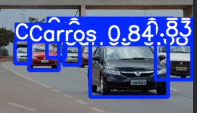

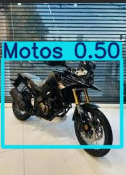

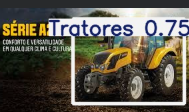

Conforme pode ser notado na evolução com 40 epochs de treinamento tivemos os seguintes resultados para essas primeiras imagens de validação sendo:
- Carro com 83% identificando outros carros na imagem
- Moto com 50% de precisão
- Trator com 75% de precisão


## Treinamento da Rede Yolo com 80 epochs

In [8]:
! python yolov5/train.py --data dados.yaml --weights yolov5s.pt --img 640 --epochs 80

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-28 15:30:36.364258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777390236.385254    2973 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777390236.392494    2973 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777390236.411707    2973 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777390236.411750    2973 computation_placer.cc:177] computation placer already registere

### Resumo do treinamento da 2° Rede

1. Arquitetura
- 157 camadas - N° total de camadas da rede neural
- 7.018.216 parâmetros - Quantidade de pesos ajustáveis aprendidos.
- 0 gradientes - indica que o modelo não está sendo treinado no momento
- 15,8 GFLOPs - medida de complexidade computacional do modelo

2. Classificação dos resultados
- 3 Classes -> Carros, Motos e Tratores
- Imagens -> N° de imagens usado na avaliação
- P (Precisão) -> A previsão mostra que Tratores teve 100% de precisão, seguido de Carros com 66% e Tratores com 79% de acerto com uma média de 81.8% para o contexto geral
- R (Recall) -> Carros atingiram positivamente 100% de detecção enquanto geral foi de 76.8%
- maP50 (Média de precisão média em IoU 0.5): Seguiu com uma média de 83.9% mas Tratores se sobresaindo com uma média de 88,8%
- maP50-95 -> Carros ganhou com 58.2% enquanto Motos se saiu com 42,5%

In [9]:
import os
import subprocess

def get_latest_train_run_folder():
    subfolders = [f.path for f in os.scandir('yolov5/runs/train') if f.is_dir()]
    latest_folder = max(subfolders, key=os.path.getctime, default=None)
    return latest_folder

latest_run = get_latest_train_run_folder()
result = subprocess.run(f'python yolov5/detect.py --weights {latest_run}/weights/best.pt --img 640 --source drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/ --data yolov5/data/telhado.yaml', shell=True, capture_output=True, text=True)
if latest_run:
    # COMANDO
    result = subprocess.run(f'python yolov5/detect.py --weights {latest_run}/weights/best.pt --img 640 --source drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/ --data yolov5/data/telhado.yaml', shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
else:
    print("Não foi possível encontrar a pasta de treinamento mais recente.")


detect: weights=['yolov5/runs/train/exp2/weights/best.pt'], source=drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/, data=yolov5/data/telhado.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7018216 parameters, 0 gradients, 15.8 GFLOPs
image 1/12 /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/Carros_5.jpg: 384x640 7 Carross, 34.7ms
image 2/12 /content/drive/MyDrive/Faculdades/FIAP/2_Sem

### Resumo da Validação da 2° Rede

Como verificado foram processados 12 imagens sendo 4 de cada categoria, conforme pode ser visto abaixo com algumas descrições:

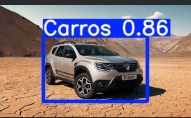

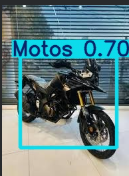

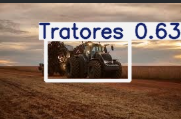

Conforme pode ser notado na evolução com 40 epochs de treinamento tivemos os seguintes resultados para essas primeiras imagens de validação sendo:
- Carro com 86% identificando outros carros na imagem
- Moto com 70% de precisão
- Trator com 63% de precisão


## Treinamento Yolo Padrão

In [16]:
!python /content/yolov5/detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test

detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/12 /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test/Carros_5.jpg: 384x640 5 cars, 4 trucks, 38.3ms
image 2/12 /content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6

### Resumo da Validação Yolo Padrão

Como verificado foram processados 12 imagens sendo 4 de cada categoria, conforme pode ser visto abaixo com algumas descrições:

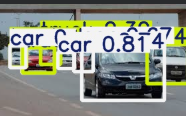

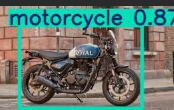

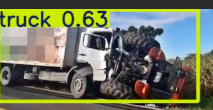

Na YOLO Padrão obtivemos
- Carro com 81% identificando outros carros na imagem
- Moto com 87% de precisão
- Trator com 63% de precisão


## Modelo com CNN Raiz

In [19]:
# Cria uma estrutura nova no drive, pois CNN precisa estar organizado corretamente nas pastas com sua categoria
import os

base_path = '/content/drive/MyDrive/FIAP_CNN'

folders = [
    'train/carros', 'train/motos', 'train/tratores',
    'valid/carros', 'valid/motos', 'valid/tratores',
    'test/carros', 'test/motos', 'test/tratores'
]

for f in folders:
    os.makedirs(os.path.join(base_path, f), exist_ok=True)

print("Estrutura criada com sucesso.")

Estrutura criada com sucesso.


In [21]:
# Reorganizar automaticamente
import shutil

source_train = '/content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/images/Treino'
source_valid = '/content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/images/Validacao'
source_test  = '/content/drive/MyDrive/Faculdades/FIAP/2_Semestre/Fase_6/Atividades/Cap_1_O_despertar_da_Rede_Neural/test'

dest_base = '/content/drive/MyDrive/FIAP_CNN'

def mover_imagens(origem, destino_tipo):
    for img in os.listdir(origem):
        img_path = os.path.join(origem, img)

        if not img.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue

        nome = img.lower()

        if 'carro' in nome:
            destino = 'carros'
        elif 'moto' in nome:
            destino = 'motos'
        elif 'trator' in nome:
            destino = 'tratores'
        else:
            continue

        shutil.copy(img_path, os.path.join(dest_base, destino_tipo, destino))

# Executa
mover_imagens(source_train, 'train')
mover_imagens(source_valid, 'valid')
mover_imagens(source_test, 'test')

print("Imagens organizadas com sucesso.")

Imagens organizadas com sucesso.


In [22]:
# Carregamento
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/FIAP_CNN/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/FIAP_CNN/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 126 images belonging to 3 classes.
Found 12 images belonging to 3 classes.


In [23]:
# Modelo CNN
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')  # 3 classes
])

In [24]:
# Compilação
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# Treinamento
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 922ms/step - accuracy: 0.3968 - loss: 1.8766 - val_accuracy: 0.3333 - val_loss: 1.1019
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.3651 - loss: 1.1047 - val_accuracy: 0.3333 - val_loss: 1.1097
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.4286 - loss: 1.0550 - val_accuracy: 0.4167 - val_loss: 1.0630
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.4841 - loss: 1.0089 - val_accuracy: 0.4167 - val_loss: 1.0584
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.5714 - loss: 0.9499 - val_accuracy: 0.5833 - val_loss: 1.0461
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 478ms/step - accuracy: 0.6111 - loss: 0.8876 - val_accuracy: 0.4167 - val_loss: 1.2129
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 386ms/step - accuracy: 0.6429 - loss: 0.8399 - val_accuracy: 0.2500 - val_loss: 1.2250
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.6905 - loss: 0.7645 - val_accuracy: 0.2500 - val_loss

In [26]:
test_data = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/FIAP_CNN/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, acc = model.evaluate(test_data)

print(f"Acurácia no teste: {acc:.4f}")

Found 12 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5000 - loss: 1.4534
Acurácia no teste: 0.5000


A CNN apresentou acurácia de aproximadamente 50%, valor acima do baseline aleatório (~33% para 3 classes), porém inferior ao modelo YOLO.

Esse comportamento é esperado devido a:

- Baixo volume de dados disponíveis
- Treinamento do modelo do zero (sem transfer learning)
- Incapacidade da CNN em lidar com múltiplos objetos por imagem
- Maior sensibilidade a variações de fundo e escala

Diferentemente do YOLO, que realiza detecção espacial, a CNN realiza apenas classificação global da imagem, o que limita sua performance neste cenário.